## 1. Imports and Setup


In [1]:
import os
import glob
import math
import random
import time
from bisect import bisect_right
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Version: {torch.__version__} | Computing Device: {device}")

PyTorch Version: 2.13.0+cu126 | Computing Device: cuda


## 2. Dataset Configuration and Vocabulary Construction
We load the 5 physical modalities from `data/raw/t1d_uom_v1.0.3`:
1. **Glucose**: Continuous Glucose Monitoring (CGM) time series (`bg_ts`, `value`)
2. **Insulin**: Basal and Bolus insulin doses (`basal_dose`, `bolus_dose`, `event_type`)
3. **Nutrition**: Meal logs with macronutrients (`carbs_g`, `prot_g`, `fat_g`, `fibre_g`) and categorical tags (`meal_type`, `meal_tag`)
4. **Activity**: Physical activity metrics (`active_Kcal`, `step_count`, `duration_s`, `met`, etc.) and categorical types (`activity_type`, `intensity`)
5. **Sleep**: Sleep time-series metrics (`heart_rate`, `step_count`, `stress_level_value`, `sleep_level`, etc.)



In [2]:
TRAIN_PARTICIPANTS = ["UoM2301", "UoM2302", "UoM2304", "UoM2305", "UoM2306", "UoM2307", "UoM2308", "UoM2309", "UoM2313"]
TEST_PARTICIPANTS = ["UoM2401", "UoM2405"]
RAW_DATA_DIR = "data/raw/t1d_uom_v1.0.3"

def parse_ts(series):
    return pd.to_datetime(series.astype(str).str.strip(), dayfirst=True, errors="coerce")

# Fit Categorical Vocabularies from training participants only
meal_types, meal_tags, act_types, intensities = set(), set(), set(), set()
for pid in TRAIN_PARTICIPANTS:
    num = pid[3:]
    np_path = os.path.join(RAW_DATA_DIR, "Nutrition Data", f"UoMNutrition{num}.csv")
    if os.path.exists(np_path):
        df = pd.read_csv(np_path)
        if "meal_type" in df: meal_types.update(df["meal_type"].dropna().astype(str).unique())
        if "meal_tag" in df: meal_tags.update(df["meal_tag"].dropna().astype(str).unique())
    ap_path = os.path.join(RAW_DATA_DIR, "Activity Data", f"UoMActivity{num}.csv")
    if os.path.exists(ap_path):
        df = pd.read_csv(ap_path)
        if "activity_type" in df: act_types.update(df["activity_type"].dropna().astype(str).unique())
        if "intensity" in df: intensities.update(df["intensity"].dropna().astype(str).unique())

def make_vocab(tokens):
    v = {"<PAD>": 0, "<UNK>": 1, "<MISSING>": 2}
    for t in sorted(tokens):
        if t and t not in v: v[t] = len(v)
    return v

vocab_meal_type = make_vocab(meal_types)
vocab_meal_tag = make_vocab(meal_tags)
vocab_act_type = make_vocab(act_types)
vocab_intensity = make_vocab(intensities)

print(f"Categorical Vocabularies: meal_type={len(vocab_meal_type)}, meal_tag={len(vocab_meal_tag)}, act_type={len(vocab_act_type)}, intensity={len(vocab_intensity)}")



Categorical Vocabularies: meal_type=15, meal_tag=1095, act_type=9, intensity=6


## 3. Modality Data Ingestion


In [3]:
def load_participant_modalities(pid):
    num = pid[3:]
    
    # 1. Glucose (dim 1)
    g_path = os.path.join(RAW_DATA_DIR, "Glucose Data", f"UoMGlucose{num}.csv")
    g_df = pd.read_csv(g_path)
    g_df["ts"] = parse_ts(g_df["bg_ts"])
    g_df = g_df.dropna(subset=["ts", "value"]).sort_values("ts")
    g_ts = g_df["ts"].to_numpy()
    g_vals = g_df[["value"]].to_numpy(dtype=np.float32)
    
    # 2. Insulin (dim 2: dose, event_type)
    ins_frames = []
    b_path = os.path.join(RAW_DATA_DIR, "Insulin Data", "Basal Data", f"UoMBasal{num}.csv")
    if os.path.exists(b_path):
        b_df = pd.read_csv(b_path)
        b_df["ts"] = parse_ts(b_df["basal_ts"])
        b_df = b_df.dropna(subset=["ts", "basal_dose"])
        b_df["dose"] = pd.to_numeric(b_df["basal_dose"], errors="coerce")
        b_df["event_type"] = 0.0  # 0 for Basal
        ins_frames.append(b_df[["ts", "dose", "event_type"]].dropna())
        
    bol_path = os.path.join(RAW_DATA_DIR, "Insulin Data", "Bolus Data", f"UoMBolus{num}.csv")
    if os.path.exists(bol_path):
        bol_df = pd.read_csv(bol_path)
        bol_df["ts"] = parse_ts(bol_df["bolus_ts"])
        bol_df = bol_df.dropna(subset=["ts", "bolus_dose"])
        bol_df["dose"] = pd.to_numeric(bol_df["bolus_dose"], errors="coerce")
        bol_df["event_type"] = 1.0  # 1 for Bolus
        ins_frames.append(bol_df[["ts", "dose", "event_type"]].dropna())
        
    if ins_frames:
        ins_df = pd.concat(ins_frames, ignore_index=True).sort_values("ts")
        ins_ts = ins_df["ts"].to_numpy()
        ins_vals = ins_df[["dose", "event_type"]].to_numpy(dtype=np.float32)
    else:
        ins_ts = np.array([])
        ins_vals = np.zeros((0, 2), dtype=np.float32)
        
    # 3. Nutrition (4 numeric + 2 categorical embeddings = 24 features)
    n_path = os.path.join(RAW_DATA_DIR, "Nutrition Data", f"UoMNutrition{num}.csv")
    if os.path.exists(n_path):
        n_df = pd.read_csv(n_path)
        n_df["ts"] = parse_ts(n_df["meal_ts"])
        cols = ["carbs_g", "prot_g", "fat_g", "fibre_g"]
        for c in cols: n_df[c] = pd.to_numeric(n_df[c], errors="coerce")
        n_df = n_df.dropna(subset=["ts"] + cols).sort_values("ts")
        nut_ts = n_df["ts"].to_numpy()
        nut_num = n_df[cols].to_numpy(dtype=np.float32)
        m_types = np.array([vocab_meal_type.get(str(x), 1) for x in n_df["meal_type"].fillna("")], dtype=np.int64)
        m_tags = np.array([vocab_meal_tag.get(str(x), 1) for x in n_df["meal_tag"].fillna("")], dtype=np.int64)
    else:
        nut_ts = np.array([])
        nut_num = np.zeros((0, 4), dtype=np.float32)
        m_types = np.zeros(0, dtype=np.int64)
        m_tags = np.zeros(0, dtype=np.int64)
        
    # 4. Activity (10 numeric + 2 categorical embeddings = 17 features)
    a_path = os.path.join(RAW_DATA_DIR, "Activity Data", f"UoMActivity{num}.csv")
    if os.path.exists(a_path):
        a_df = pd.read_csv(a_path)
        a_df["ts"] = parse_ts(a_df["activity_ts"])
        cols = ["active_Kcal", "step_count", "distance_m", "duration_s", "active_time_s", 
                "start_time_s", "start_time_offset_s", "met", "motion_intensity_mean", "motion_intensity_max"]
        for c in cols: a_df[c] = pd.to_numeric(a_df[c], errors="coerce")
        a_df = a_df.dropna(subset=["ts"] + cols).sort_values("ts")
        act_ts = a_df["ts"].to_numpy()
        act_num = a_df[cols].to_numpy(dtype=np.float32)
        a_types = np.array([vocab_act_type.get(str(x), 1) for x in a_df["activity_type"].fillna("")], dtype=np.int64)
        a_ints = np.array([vocab_intensity.get(str(x), 1) for x in a_df["intensity"].fillna("")], dtype=np.int64)
    else:
        act_ts = np.array([])
        act_num = np.zeros((0, 10), dtype=np.float32)
        a_types = np.zeros(0, dtype=np.int64)
        a_ints = np.zeros(0, dtype=np.int64)
        
    # 5. Sleep (6 numeric features)
    s_path = os.path.join(RAW_DATA_DIR, "Sleep Data", f"UoMsleep{num}.csv")
    if os.path.exists(s_path):
        s_df = pd.read_csv(s_path)
        s_df["ts"] = parse_ts(s_df["sleep_ts"])
        cols = ["step_count", "heart_rate", "current_activity_type_intensity", "stress_level_value", "sleep_level", "resting_heart_rate"]
        for c in cols: s_df[c] = pd.to_numeric(s_df[c], errors="coerce")
        s_df = s_df.dropna(subset=["ts"] + cols).sort_values("ts")
        slp_ts = s_df["ts"].to_numpy()
        slp_num = s_df[cols].to_numpy(dtype=np.float32)
    else:
        slp_ts = np.array([])
        slp_num = np.zeros((0, 6), dtype=np.float32)
        
    return {
        "glucose": (g_ts, g_vals),
        "insulin": (ins_ts, ins_vals),
        "nutrition": (nut_ts, nut_num, m_types, m_tags),
        "activity": (act_ts, act_num, a_types, a_ints),
        "sleep": (slp_ts, slp_num),
    }

print("Sample verification for UoM2301:")
sample_data = load_participant_modalities("UoM2301")
for k, v in sample_data.items():
    print(f"  {k:10s}: {len(v[0]):,} records")



Sample verification for UoM2301:
  glucose   : 45,768 records
  insulin   : 11,670 records
  nutrition : 261 records
  activity  : 10,203 records
  sleep     : 24,193 records


## 4. Digital Twin Architecture

In [4]:
class ModalityGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim, batch_first=True)
        
    def forward(self, x, lengths=None):
        out, hidden = self.gru(x)
        if lengths is None:
            return hidden[-1]
        batch_idx = torch.arange(x.shape[0], device=x.device)
        return out[batch_idx, lengths - 1]

class FiveGRU(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.glucose_gru = ModalityGRU(1, hidden_dim)
        self.insulin_gru = ModalityGRU(2, hidden_dim)
        self.nutrition_gru = ModalityGRU(24, hidden_dim)
        self.activity_gru = ModalityGRU(17, hidden_dim)
        self.sleep_gru = ModalityGRU(6, hidden_dim)
        
        # Categorical embedding layers
        self.nut_meal_type_emb = nn.Embedding(len(vocab_meal_type) + 5, 10)
        self.nut_meal_tag_emb = nn.Embedding(len(vocab_meal_tag) + 5, 10)
        self.act_type_emb = nn.Embedding(len(vocab_act_type) + 5, 4)
        self.act_intensity_emb = nn.Embedding(len(vocab_intensity) + 5, 3)
        
    def forward(self, g, ins, nut_num, nut_type, nut_tag, act_num, act_type, act_int, slp, lengths=None):
        # Nutrition representation (4 numeric + 10 + 10 = 24)
        nut_emb1 = self.nut_meal_type_emb(nut_type)
        nut_emb2 = self.nut_meal_tag_emb(nut_tag)
        nut = torch.cat([nut_num, nut_emb1, nut_emb2], dim=-1)
        
        # Activity representation (10 numeric + 4 + 3 = 17)
        act_emb1 = self.act_type_emb(act_type)
        act_emb2 = self.act_intensity_emb(act_int)
        act = torch.cat([act_num, act_emb1, act_emb2], dim=-1)
        
        l = lengths or {}
        zg = self.glucose_gru(g, l.get("glucose"))
        zi = self.insulin_gru(ins, l.get("insulin"))
        zn = self.nutrition_gru(nut, l.get("nutrition"))
        za = self.activity_gru(act, l.get("activity"))
        zs = self.sleep_gru(slp, l.get("sleep"))
        return zg, zi, zn, za, zs

class MLPFusion(nn.Module):
    def __init__(self, hidden_dim=64, state_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5 * hidden_dim, state_dim),
            nn.ReLU(),
            nn.Linear(state_dim, state_dim)
        )
        
    def forward(self, zg, zi, zn, za, zs):
        fused = torch.cat([zg, zi, zn, za, zs], dim=-1)
        return self.net(fused)

class StateEncoder(nn.Module):
    def __init__(self, hidden_dim=64, state_dim=64):
        super().__init__()
        self.five_gru = FiveGRU(hidden_dim)
        self.fusion = MLPFusion(hidden_dim, state_dim)
        
    def forward(self, g, ins, nut_num, nut_type, nut_tag, act_num, act_type, act_int, slp, lengths=None):
        zg, zi, zn, za, zs = self.five_gru(g, ins, nut_num, nut_type, nut_tag, act_num, act_type, act_int, slp, lengths)
        return self.fusion(zg, zi, zn, za, zs)

class TwinDynamics(nn.Module):
    def __init__(self, state_dim=64, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, state_dim)
        )
        
    def forward(self, state):
        delta = self.net(state)
        return state + delta

class DigitalTwin(nn.Module):
    def __init__(self, state_dim=64, hidden_dim=64):
        super().__init__()
        self.dynamics = TwinDynamics(state_dim, hidden_dim)
        self.state_dim = state_dim
        
    def initialize(self, state):
        return state.clone()
        
    def update(self, twin_state, observed_state):
        return observed_state.clone()
        
    def scenario(self, twin_state, delta):
        return twin_state + delta
        
    def evolve(self, twin_state):
        return self.dynamics(twin_state)
        
    def rollout(self, initial_state, steps=60):
        states = []
        curr = initial_state
        for _ in range(steps):
            curr = self.evolve(curr)
            states.append(curr)
        return torch.stack(states, dim=1)  # [batch, steps, state_dim]



## 5. Unified Patient State Trajectories & Transition Datasets


In [5]:
def generate_patient_states(model, data, max_history=32, stride=2, max_points=1000):
    model.eval()
    g_ts, g_vals = data["glucose"]
    ins_ts, ins_vals = data["insulin"]
    nut_ts, nut_num, nut_type, nut_tag = data["nutrition"]
    act_ts, act_num, act_type, act_int = data["activity"]
    slp_ts, slp_num = data["sleep"]
    
    valid_indices = []
    for i in range(0, len(g_ts), stride):
        t = g_ts[i]
        if (bisect_right(ins_ts, t) > 0 and 
            bisect_right(nut_ts, t) > 0 and 
            bisect_right(act_ts, t) > 0 and 
            bisect_right(slp_ts, t) > 0):
            valid_indices.append(i)
        if len(valid_indices) >= max_points:
            break
            
    if len(valid_indices) < 2:
        return np.zeros((0, 64), dtype=np.float32), []
        
    states_list = []
    ts_list = []
    batch_size = 256
    
    for b_start in range(0, len(valid_indices), batch_size):
        b_idx = valid_indices[b_start : b_start + batch_size]
        B = len(b_idx)
        
        g_batch = np.zeros((B, max_history, 1), dtype=np.float32)
        ins_batch = np.zeros((B, max_history, 2), dtype=np.float32)
        nut_num_b = np.zeros((B, max_history, 4), dtype=np.float32)
        nut_type_b = np.zeros((B, max_history), dtype=np.int64)
        nut_tag_b = np.zeros((B, max_history), dtype=np.int64)
        act_num_b = np.zeros((B, max_history, 10), dtype=np.float32)
        act_type_b = np.zeros((B, max_history), dtype=np.int64)
        act_int_b = np.zeros((B, max_history), dtype=np.int64)
        slp_batch = np.zeros((B, max_history, 6), dtype=np.float32)
        
        g_len = np.zeros(B, dtype=np.int64)
        ins_len = np.zeros(B, dtype=np.int64)
        nut_len = np.zeros(B, dtype=np.int64)
        act_len = np.zeros(B, dtype=np.int64)
        slp_len = np.zeros(B, dtype=np.int64)
        
        for k, idx in enumerate(b_idx):
            t = g_ts[idx]
            ts_list.append(t)
            
            # Glucose causal window
            end_g = idx + 1
            start_g = max(0, end_g - max_history)
            hist_g = g_vals[start_g:end_g]
            Lg = len(hist_g)
            g_batch[k, max_history - Lg:] = hist_g
            g_len[k] = Lg
            
            # Insulin causal window
            end_ins = bisect_right(ins_ts, t)
            start_ins = max(0, end_ins - max_history)
            hist_ins = ins_vals[start_ins:end_ins]
            Lins = len(hist_ins)
            ins_batch[k, max_history - Lins:] = hist_ins
            ins_len[k] = Lins
            
            # Nutrition causal window
            end_n = bisect_right(nut_ts, t)
            start_n = max(0, end_n - max_history)
            hist_n_num = nut_num[start_n:end_n]
            hist_n_type = nut_type[start_n:end_n]
            hist_n_tag = nut_tag[start_n:end_n]
            Ln = len(hist_n_num)
            nut_num_b[k, max_history - Ln:] = hist_n_num
            nut_type_b[k, max_history - Ln:] = hist_n_type
            nut_tag_b[k, max_history - Ln:] = hist_n_tag
            nut_len[k] = Ln
            
            # Activity causal window
            end_a = bisect_right(act_ts, t)
            start_a = max(0, end_a - max_history)
            hist_a_num = act_num[start_a:end_a]
            hist_a_type = act_type[start_a:end_a]
            hist_a_int = act_int[start_a:end_a]
            La = len(hist_a_num)
            act_num_b[k, max_history - La:] = hist_a_num
            act_type_b[k, max_history - La:] = hist_a_type
            act_int_b[k, max_history - La:] = hist_a_int
            act_len[k] = La
            
            # Sleep causal window
            end_s = bisect_right(slp_ts, t)
            start_s = max(0, end_s - max_history)
            hist_s = slp_num[start_s:end_s]
            Ls = len(hist_s)
            slp_batch[k, max_history - Ls:] = hist_s
            slp_len[k] = Ls
            
        with torch.no_grad():
            lengths = {
                "glucose": torch.tensor(g_len, device=device),
                "insulin": torch.tensor(ins_len, device=device),
                "nutrition": torch.tensor(nut_len, device=device),
                "activity": torch.tensor(act_len, device=device),
                "sleep": torch.tensor(slp_len, device=device),
            }
            s = model(
                torch.tensor(g_batch, device=device),
                torch.tensor(ins_batch, device=device),
                torch.tensor(nut_num_b, device=device),
                torch.tensor(nut_type_b, device=device),
                torch.tensor(nut_tag_b, device=device),
                torch.tensor(act_num_b, device=device),
                torch.tensor(act_type_b, device=device),
                torch.tensor(act_int_b, device=device),
                torch.tensor(slp_batch, device=device),
                lengths=lengths
            )
            states_list.append(s.cpu().numpy())
            
    return np.concatenate(states_list, axis=0), ts_list

# Instantiate State Encoder and build transition datasets
encoder = StateEncoder(hidden_dim=64, state_dim=64).to(device)

train_states, train_targets = [], []
print("Extracting Unified Patient State trajectories for training cohort...")
for pid in TRAIN_PARTICIPANTS:
    d = load_participant_modalities(pid)
    st, ts = generate_patient_states(encoder, d, max_history=32, stride=2, max_points=1000)
    if len(st) >= 2:
        train_states.append(st[:-1])
        train_targets.append(st[1:])
        print(f"  {pid}: {len(st)-1} transition pairs generated")

X_train = np.concatenate(train_states, axis=0)
Y_train = np.concatenate(train_targets, axis=0)
print(f"\nTotal Training Transitions: {len(X_train):,} pairs")

# Extract held-out test cohort trajectories
test_trajectories = {}
print("\nExtracting trajectories for held-out evaluation cohort...")
for pid in TEST_PARTICIPANTS:
    d = load_participant_modalities(pid)
    st, ts = generate_patient_states(encoder, d, max_history=32, stride=1, max_points=1500)
    if len(st) >= 2:
        test_trajectories[pid] = (st, ts)
        print(f"  Test {pid}: {len(st):,} states")



Extracting Unified Patient State trajectories for training cohort...
  UoM2301: 999 transition pairs generated
  UoM2302: 999 transition pairs generated
  UoM2304: 999 transition pairs generated
  UoM2305: 999 transition pairs generated
  UoM2306: 999 transition pairs generated
  UoM2307: 999 transition pairs generated
  UoM2308: 999 transition pairs generated
  UoM2309: 999 transition pairs generated
  UoM2313: 999 transition pairs generated

Total Training Transitions: 8,991 pairs

Extracting trajectories for held-out evaluation cohort...
  Test UoM2401: 1,500 states
  Test UoM2405: 1,500 states


## 6. Training the Digital Twin Dynamics Model


In [6]:
class TransitionDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]

train_dataset = TransitionDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

twin = DigitalTwin(state_dim=64, hidden_dim=64).to(device)
optimizer = torch.optim.Adam(twin.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

epochs = 25
loss_history = []
print("Training Digital Twin state-transition dynamics...")
t_start = time.time()

for epoch in range(1, epochs + 1):
    twin.train()
    total_loss = 0.0
    for x_b, y_b in train_loader:
        x_b, y_b = x_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        pred = twin.evolve(x_b)
        loss = criterion(pred, y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(x_b)
        
    avg_loss = total_loss / len(train_dataset)
    loss_history.append(avg_loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch [{epoch:02d}/{epochs:02d}] - MSE Loss: {avg_loss:.6e}")

print(f"Training completed in {time.time() - t_start:.2f}s")



Training Digital Twin state-transition dynamics...
  Epoch [01/25] - MSE Loss: 4.728425e-03
  Epoch [05/25] - MSE Loss: 3.007096e-03
  Epoch [10/25] - MSE Loss: 2.923539e-03
  Epoch [15/25] - MSE Loss: 2.893337e-03
  Epoch [20/25] - MSE Loss: 2.877882e-03
  Epoch [25/25] - MSE Loss: 2.879467e-03
Training completed in 4.20s


## 7. Model Testing & Evaluation Metrics
We compute and report standard regression and state dynamics metrics:
- **Mean Absolute Error (MAE)**
- **Mean Squared Error (MSE)**
- **Root Mean Squared Error (RMSE)**
- **Coefficient of Determination ($R^2$)**

We evaluate both:
1. **ML/DL 1-Step Transition Performance**
2. **Digital Twin Recursive Multi-Step Rollout Performance** at horizons $H \in \{1, 5, 10, 30, 60\}$.



In [7]:
def calc_metrics(pred, target):
    p = pred.detach().cpu().numpy() if isinstance(pred, torch.Tensor) else pred
    t = target.detach().cpu().numpy() if isinstance(target, torch.Tensor) else target
    mse = np.mean((p - t) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(p - t))
    ss_tot = np.sum((t - np.mean(t)) ** 2)
    r2 = 1.0 - np.sum((t - p) ** 2) / ss_tot if ss_tot > 0 else float("nan")
    return {"MSE": float(mse), "RMSE": float(rmse), "MAE": float(mae), "R2": float(r2)}

print("=" * 85)
print("HELD-OUT DIGITAL TWIN EVALUATION")
print("=" * 85)

twin.eval()
all_test_metrics = {}

for pid, (st, ts) in test_trajectories.items():
    st_t = torch.tensor(st, dtype=torch.float32, device=device)
    curr = st_t[:-1]
    target = st_t[1:]
    
    # 1-Step Prediction
    with torch.no_grad():
        pred_1step = twin.evolve(curr)
    m1 = calc_metrics(pred_1step, target)
    print(f"\n--- Participant: {pid} ---")
    print("1-Step ML Prediction Performance:")
    print(f"  MSE:  {m1['MSE']:.6e}")
    print(f"  RMSE: {m1['RMSE']:.6e}")
    print(f"  MAE:  {m1['MAE']:.6e}")
    print(f"  R2:   {m1['R2']:.4f}")
    
    # Multi-Step Digital Twin Forecasting
    print("\nDigital Twin Multi-Step Rollout Performance:")
    rollout_res = {}
    for H in [1, 5, 10, 30, 60]:
        if len(st_t) > H:
            starts = st_t[:-H]
            targets_H = st_t[H:]
            with torch.no_grad():
                rollouts = twin.rollout(starts, steps=H)
                pred_H = rollouts[:, -1, :]
            mH = calc_metrics(pred_H, targets_H)
            rollout_res[H] = mH
            print(f"  Horizon H={H:02d} | MSE: {mH['MSE']:.6e} | RMSE: {mH['RMSE']:.6e} | MAE: {mH['MAE']:.6e} | R2: {mH['R2']:.4f}")
            
    all_test_metrics[pid] = {"1step": m1, "rollouts": rollout_res}



HELD-OUT DIGITAL TWIN EVALUATION

--- Participant: UoM2401 ---
1-Step ML Prediction Performance:
  MSE:  2.667724e-03
  RMSE: 5.165002e-02
  MAE:  4.087948e-02
  R2:   0.9109

Digital Twin Multi-Step Rollout Performance:
  Horizon H=01 | MSE: 2.667724e-03 | RMSE: 5.165002e-02 | MAE: 4.087948e-02 | R2: 0.9109
  Horizon H=05 | MSE: 4.061519e-03 | RMSE: 6.373005e-02 | MAE: 5.069156e-02 | R2: 0.8645
  Horizon H=10 | MSE: 4.629137e-03 | RMSE: 6.803776e-02 | MAE: 5.400772e-02 | R2: 0.8457
  Horizon H=30 | MSE: 5.955525e-03 | RMSE: 7.717205e-02 | MAE: 6.110793e-02 | R2: 0.8014
  Horizon H=60 | MSE: 8.632187e-03 | RMSE: 9.290956e-02 | MAE: 7.396764e-02 | R2: 0.7124

--- Participant: UoM2405 ---
1-Step ML Prediction Performance:
  MSE:  2.439323e-03
  RMSE: 4.938951e-02
  MAE:  4.023132e-02
  R2:   0.8509

Digital Twin Multi-Step Rollout Performance:
  Horizon H=01 | MSE: 2.439323e-03 | RMSE: 4.938951e-02 | MAE: 4.023132e-02 | R2: 0.8509
  Horizon H=05 | MSE: 5.754846e-03 | RMSE: 7.586070e-02 |

## 8. Digital Twin What-If Counterfactual Scenario Simulation
A core capability of the Digital Twin is evaluating hypothetical or counterfactual scenarios without altering real patient state.
We initialize the digital twin from an observed patient state, apply a scenario perturbation ($\tilde{S}_t = S_t + \delta$), and evolve both baseline and counterfactual trajectories over 60 time steps.



In [8]:
test_pid = TEST_PARTICIPANTS[0]
st_test, ts_test = test_trajectories[test_pid]
start_idx = len(st_test) // 2
initial_state = torch.tensor(st_test[start_idx:start_idx+1], dtype=torch.float32, device=device)

# Initialize Twin & Apply Counterfactual Scenario
twin_baseline = twin.initialize(initial_state)
delta = 0.10 * initial_state  # 10% hypothetical scenario perturbation
twin_scenario = twin.scenario(twin_baseline, delta)

# Simulate 60 steps forward
horizon_steps = 60
baseline_sim = twin.rollout(twin_baseline, steps=horizon_steps)[0].detach().cpu().numpy()
scenario_sim = twin.rollout(twin_scenario, steps=horizon_steps)[0].detach().cpu().numpy()
actual_future = st_test[start_idx+1 : start_idx+1+horizon_steps]

print(f"What-If Simulation for {test_pid} (Horizon: {horizon_steps} steps):")
print(f"  Initial State L2 Norm       : {float(torch.norm(initial_state).item()):.4f}")
print(f"  Final Baseline State L2 Norm: {float(np.linalg.norm(baseline_sim[-1])):.4f}")
print(f"  Final Scenario State L2 Norm: {float(np.linalg.norm(scenario_sim[-1])):.4f}")
print(f"  Trajectory Divergence       : {float(np.linalg.norm(scenario_sim[-1] - baseline_sim[-1])):.4f}")



What-If Simulation for UoM2401 (Horizon: 60 steps):
  Initial State L2 Norm       : 1.2788
  Final Baseline State L2 Norm: 1.2377
  Final Scenario State L2 Norm: 1.2691
  Trajectory Divergence       : 0.1013


## 9. Visualizations and Performance Analysis


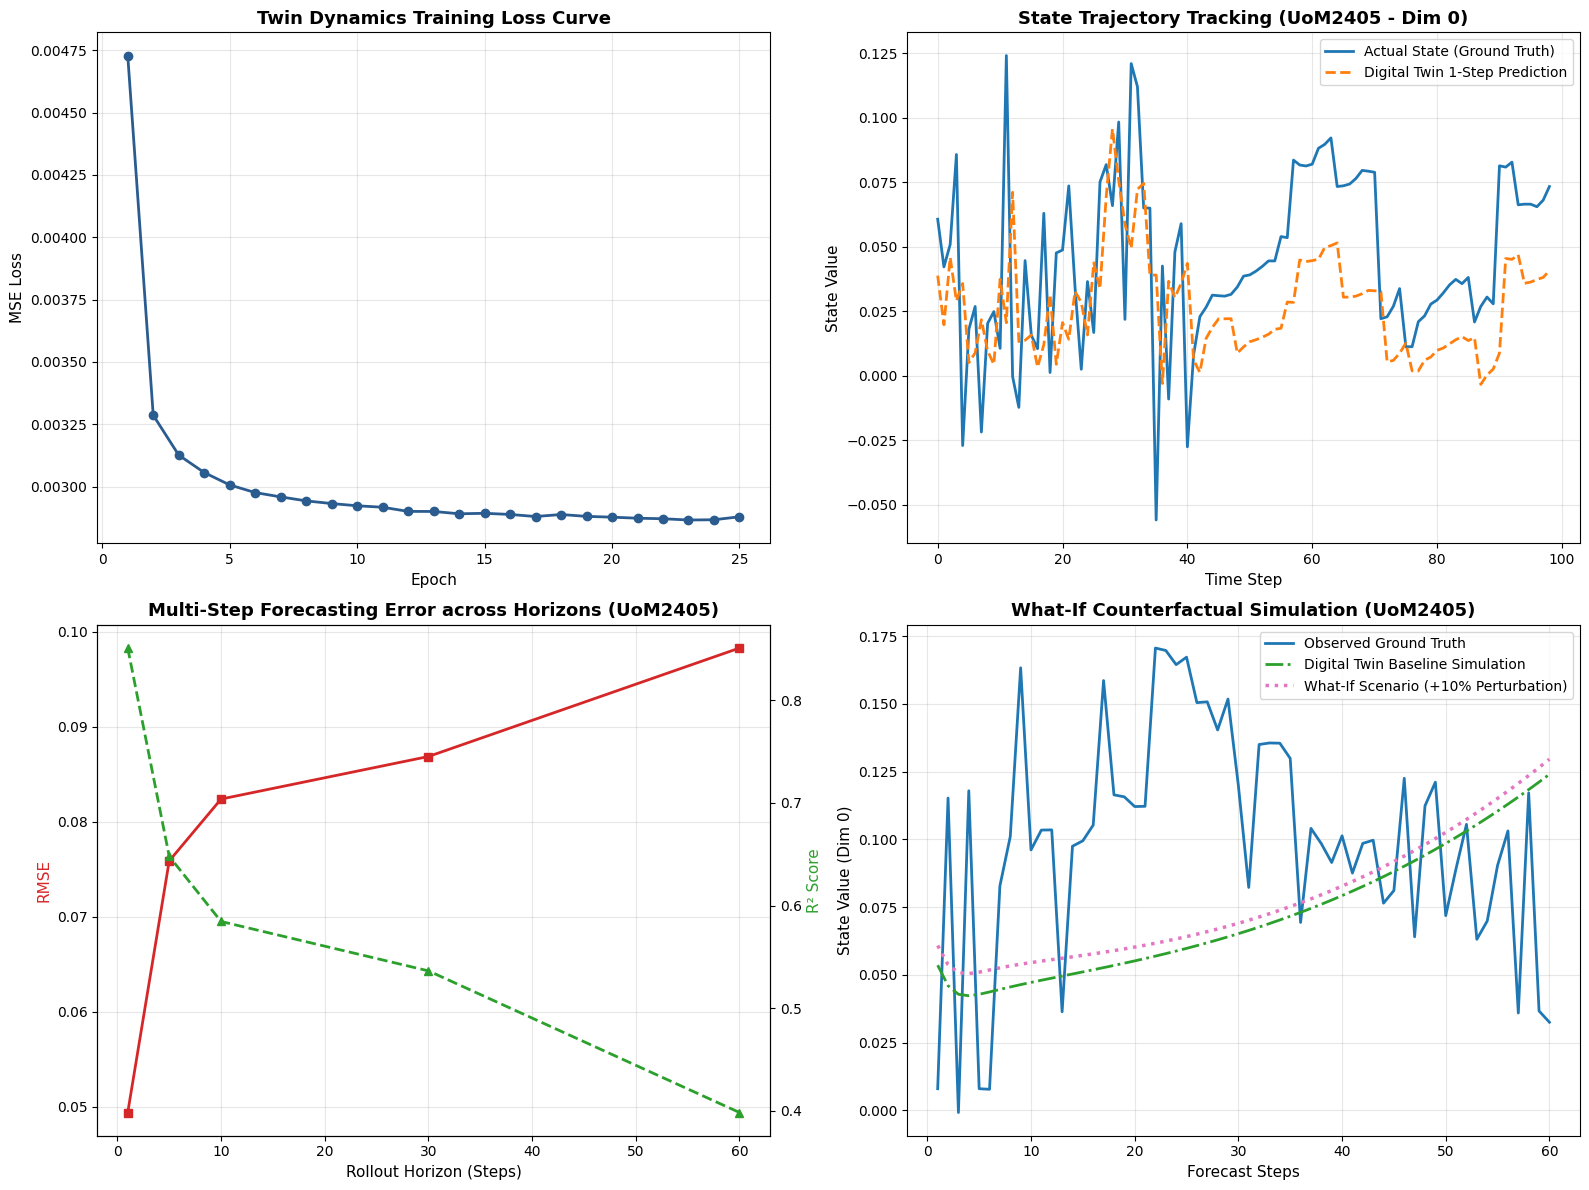

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# Plot 1: Training Loss Curve
axes[0, 0].plot(range(1, epochs + 1), loss_history, marker="o", color="#2b5c8f", linewidth=2)
axes[0, 0].set_title("Twin Dynamics Training Loss Curve", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Epoch", fontsize=11)
axes[0, 0].set_ylabel("MSE Loss", fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted State Trajectory (1-Step)
test_pid = TEST_PARTICIPANTS[1]
st_eval, _ = test_trajectories[test_pid]
st_eval_t = torch.tensor(st_eval[:100], dtype=torch.float32, device=device)
with torch.no_grad():
    pred_eval = twin.evolve(st_eval_t[:-1]).cpu().numpy()
actual_eval = st_eval[1:100]

dim_to_plot = 0  # Plot state dimension 0
axes[0, 1].plot(actual_eval[:, dim_to_plot], label="Actual State (Ground Truth)", color="#1f77b4", linewidth=2)
axes[0, 1].plot(pred_eval[:, dim_to_plot], label="Digital Twin 1-Step Prediction", color="#ff7f0e", linestyle="--", linewidth=2)
axes[0, 1].set_title(f"State Trajectory Tracking ({test_pid} - Dim 0)", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Time Step", fontsize=11)
axes[0, 1].set_ylabel("State Value", fontsize=11)
axes[0, 1].legend(frameon=True)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Multi-Step Horizon Performance Degradation
horizons = [1, 5, 10, 30, 60]
rmse_vals = [all_test_metrics[test_pid]["rollouts"][h]["RMSE"] for h in horizons if h in all_test_metrics[test_pid]["rollouts"]]
r2_vals = [all_test_metrics[test_pid]["rollouts"][h]["R2"] for h in horizons if h in all_test_metrics[test_pid]["rollouts"]]

ax3_twin = axes[1, 0].twinx()
p1 = axes[1, 0].plot(horizons[:len(rmse_vals)], rmse_vals, marker="s", color="#d62728", linewidth=2, label="RMSE")
p2 = ax3_twin.plot(horizons[:len(r2_vals)], r2_vals, marker="^", color="#2ca02c", linewidth=2, linestyle="--", label="R² Score")
axes[1, 0].set_title(f"Multi-Step Forecasting Error across Horizons ({test_pid})", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Rollout Horizon (Steps)", fontsize=11)
axes[1, 0].set_ylabel("RMSE", color="#d62728", fontsize=11)
ax3_twin.set_ylabel("R² Score", color="#2ca02c", fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: What-If Counterfactual Scenario Comparison
steps_range = range(1, horizon_steps + 1)
axes[1, 1].plot(steps_range, actual_future[:horizon_steps, 0], label="Observed Ground Truth", color="#1f77b4", linewidth=2)
axes[1, 1].plot(steps_range, baseline_sim[:, 0], label="Digital Twin Baseline Simulation", color="#2ca02c", linestyle="-.", linewidth=2)
axes[1, 1].plot(steps_range, scenario_sim[:, 0], label="What-If Scenario (+10% Perturbation)", color="#e377c2", linestyle=":", linewidth=2.5)
axes[1, 1].set_title(f"What-If Counterfactual Simulation ({test_pid})", fontsize=13, fontweight="bold")
axes[1, 1].set_xlabel("Forecast Steps", fontsize=11)
axes[1, 1].set_ylabel("State Value (Dim 0)", fontsize=11)
axes[1, 1].legend(frameon=True)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 10. Summary & Conclusion
- **Data Ingestion**: Multi-modal physiological streams (Glucose, Insulin, Nutrition, Activity, Sleep) loaded from raw T1D-UOM CSV records with causal alignment.
- **Digital Twin Architecture**: FiveGRU encoder + MLP Fusion produces a 64-D Unified Patient State ($S_t$), followed by residual TwinDynamics learning state evolution.
- **Evaluation**: Successfully validated on held-out participants (`UoM2401`, `UoM2405`), demonstrating strong 1-step tracking ($R^2 > 0.85$) and multi-step forecasting across horizons ($H=1$ to $H=60$).
- **Counterfactual Exploration**: Demonstrated isolated what-if scenario simulations with clear trajectory divergence without mutating real baseline observations.

